In [7]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# Load the siamese network results
siamese_results_path = 'D:/PS-2-V2/PS-2 functions/data/results/siamese_146_result.csv'
siamese_df = pd.read_csv(siamese_results_path)

print('Siamese Network Results:')
print(siamese_df.head())
print('Unique fitness values in Siamese results:')
print(siamese_df['fitness'].unique() if 'fitness' in siamese_df.columns else 'fitness column not found')

# Load the human ranking results
human_ranking_path = 'D:/PS-2-V2/PS-2 functions/data/raw/siamese_146_result.csv'
human_df = pd.read_csv(human_ranking_path)

# Strip whitespace from all column names
human_df.columns = [col.strip() for col in human_df.columns]
print('Human Ranking Results:')
print(human_df.head())
print('Columns in human_df:', human_df.columns.tolist())

# Use explicit column names from the CSV (now stripped)
MODEL_COL = 'Fitness(model)'
EXPERT1_COL = 'Expert-1'
EXPERT2_COL = 'Expert-2'
EXPERT3_COL = 'Expert-3'

print('Unique fitness values in model column:', human_df[MODEL_COL].unique())
print('Unique fitness values in Expert1 results:', human_df[EXPERT1_COL].unique())
print('Unique fitness values in Expert2 results:', human_df[EXPERT2_COL].unique())
print('Unique fitness values in Expert3 results:', human_df[EXPERT3_COL].unique())

# Define a mapping for fitness categories to numerical values
fitness_mapping = {
    'Best Fit': 4,
    'Good Fit': 3,
    'Average Fit': 2,
    'Bad Fit': 1,
    'Not a Fit': 0,
    'Not Fit': 0  # Handle the discrepancy
}

# Apply mapping to siamese_df
if 'fitness' in siamese_df.columns:
    siamese_df['fitness_numeric'] = siamese_df['fitness'].map(fitness_mapping)
else:
    # fallback: try to use model column as fitness
    siamese_df['fitness_numeric'] = human_df[MODEL_COL].map(fitness_mapping)

# Apply mapping to human_df for all relevant columns
human_df['Model_numeric'] = human_df[MODEL_COL].map(fitness_mapping)
human_df['Expert1_numeric'] = human_df[EXPERT1_COL].map(fitness_mapping)
human_df['Expert2_numeric'] = human_df[EXPERT2_COL].map(fitness_mapping)
human_df['Expert3_numeric'] = human_df[EXPERT3_COL].map(fitness_mapping)

# Merge the dataframes on 'Name'
merged_df = pd.merge(
    siamese_df[['Name', 'fitness_numeric']],
    human_df[['Name', 'Model_numeric', 'Expert1_numeric', 'Expert2_numeric', 'Expert3_numeric']],
    on='Name',
    how='inner'
)

print('Merged DataFrame Head:')
print(merged_df.head())

# Calculate Cohen's Kappa for agreement between Siamese model and each expert
kappa_expert1 = cohen_kappa_score(merged_df['fitness_numeric'], merged_df['Expert1_numeric'])
kappa_expert2 = cohen_kappa_score(merged_df['fitness_numeric'], merged_df['Expert2_numeric'])
kappa_expert3 = cohen_kappa_score(merged_df['fitness_numeric'], merged_df['Expert3_numeric'])

print(f"Cohen's Kappa (Siamese vs Expert1): {kappa_expert1:.4f}")
print(f"Cohen's Kappa (Siamese vs Expert2): {kappa_expert2:.4f}")
print(f"Cohen's Kappa (Siamese vs Expert3): {kappa_expert3:.4f}")

# Calculate agreement between the model's fitness and the human model's fitness
kappa_model_vs_human_model = cohen_kappa_score(merged_df['fitness_numeric'], merged_df['Model_numeric'])
print(f"Cohen's Kappa (Siamese vs Human Model): {kappa_model_vs_human_model:.4f}")

# Calculate average Cohen's Kappa across experts
average_expert_kappa = (kappa_expert1 + kappa_expert2 + kappa_expert3) / 3
print(f"Average Cohen's Kappa (Siamese vs Experts): {average_expert_kappa:.4f}")

# Calculate average of the three expert scores
merged_df['Expert_Average_Numeric'] = merged_df[['Expert1_numeric', 'Expert2_numeric', 'Expert3_numeric']].mean(axis=1)

# Round the average expert score to the nearest integer to represent a fitness category
merged_df['Expert_Average_Rounded'] = merged_df['Expert_Average_Numeric'].round().astype(int)

# Calculate Cohen's Kappa between Siamese model and the rounded average expert score
kappa_siamese_vs_avg_expert = cohen_kappa_score(merged_df['fitness_numeric'], merged_df['Expert_Average_Rounded'])
print(f"Cohen's Kappa (Siamese vs Average Expert): {kappa_siamese_vs_avg_expert:.4f}")

print('Merged DataFrame with Expert Average Numeric and Rounded:')
print(merged_df.head())

Siamese Network Results:
   Unnamed: 0                        Name  similarity_score   fitness
0         129                 Divij Goyal          0.668200  Best Fit
1          73              Nishant Sharma          0.653057  Best Fit
2          80        PATLOLA ANUDEEPREDDY          0.646466  Best Fit
3         105                 Anish Kumar          0.642791  Best Fit
4          47  Jyotiraditya Singh Rathore          0.625223  Best Fit
Unique fitness values in Siamese results:
['Best Fit' 'Good Fit' 'Average Fit' 'Bad Fit' 'Not a Fit']
Human Ranking Results:
   Unnamed: 0                        Name  similarity_score Fitness(model)  \
0         129                 Divij Goyal          0.668200       Best Fit   
1          73              Nishant Sharma          0.653057       Best Fit   
2          80        PATLOLA ANUDEEPREDDY          0.646466       Best Fit   
3         105                 Anish Kumar          0.642791       Best Fit   
4          47  Jyotiraditya Singh Rathor

# Visual Comparison of Model and Expert Ranks

In this section, we will visually compare the fitness ranks assigned by the Siamese model and the human experts. We will use bar plots, scatter plots, and heatmaps to better understand the agreement and differences between the model and the experts.

## 1. Distribution of Fitness Ranks

Let's visualize the distribution of fitness ranks assigned by the model and each expert.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\957518639.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(rank_labels, rotation=45)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\957518639.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(rank_labels, rotation=45)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\957518639.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(rank_labels, rotation=45)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\957518639.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3].set_xticklabels(rank_labels, rotation=45)
C:\Users\ASUS\Ap

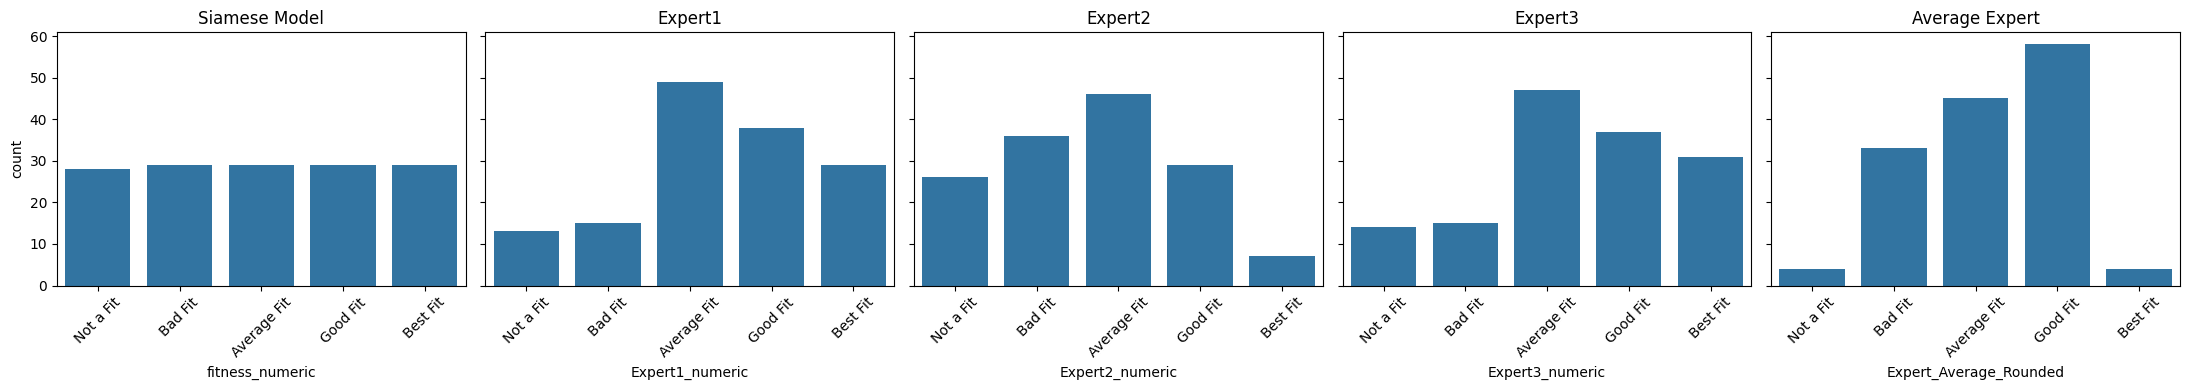

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

rank_labels = ['Not a Fit', 'Bad Fit', 'Average Fit', 'Good Fit', 'Best Fit']
rank_order = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
sns.countplot(x=merged_df['fitness_numeric'], order=rank_order, ax=axes[0])
axes[0].set_title('Siamese Model')
axes[0].set_xticklabels(rank_labels, rotation=45)
sns.countplot(x=merged_df['Expert1_numeric'], order=rank_order, ax=axes[1])
axes[1].set_title('Expert1')
axes[1].set_xticklabels(rank_labels, rotation=45)
sns.countplot(x=merged_df['Expert2_numeric'], order=rank_order, ax=axes[2])
axes[2].set_title('Expert2')
axes[2].set_xticklabels(rank_labels, rotation=45)
sns.countplot(x=merged_df['Expert3_numeric'], order=rank_order, ax=axes[3])
axes[3].set_title('Expert3')
axes[3].set_xticklabels(rank_labels, rotation=45)
sns.countplot(x=merged_df['Expert_Average_Rounded'], order=rank_order, ax=axes[4])
axes[4].set_title('Average Expert')
axes[4].set_xticklabels(rank_labels, rotation=45)
plt.tight_layout()
plt.show()

## 2. Scatter Plots: Model vs. Each Expert

Scatter plots help visualize the agreement and spread between the model's fitness scores and each expert's scores.

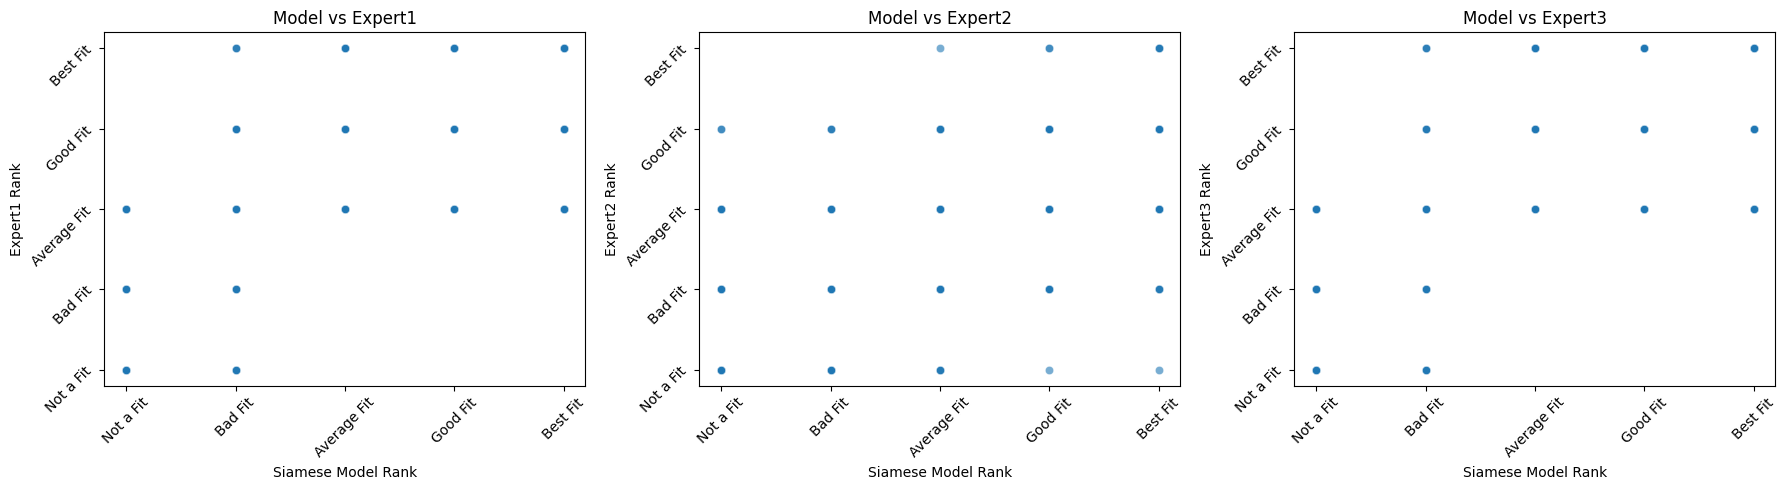

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
experts = [
    ('Expert1_numeric', 'Expert1'),
    ('Expert2_numeric', 'Expert2'),
    ('Expert3_numeric', 'Expert3')
]
for i, (col, label) in enumerate(experts):
    sns.scatterplot(x=merged_df['fitness_numeric'], y=merged_df[col], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel('Siamese Model Rank')
    axes[i].set_ylabel(f'{label} Rank')
    axes[i].set_title(f'Model vs {label}')
    axes[i].set_xticks(rank_order)
    axes[i].set_yticks(rank_order)
    axes[i].set_xticklabels(rank_labels, rotation=45)
    axes[i].set_yticklabels(rank_labels, rotation=45)
plt.tight_layout()
plt.show()

## 3. Agreement Heatmaps (Confusion Matrices)

Heatmaps show the agreement between the model and each expert by displaying the count of each (model rank, expert rank) pair.

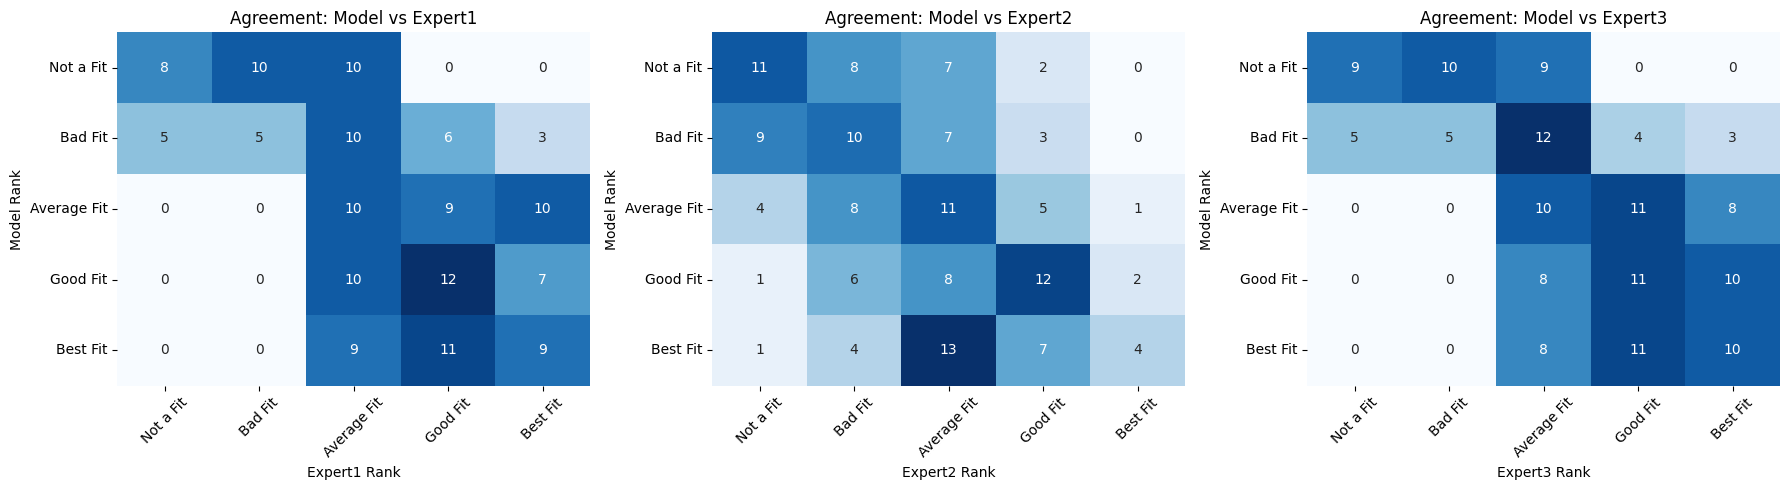

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, label) in enumerate(experts):
    cm = pd.crosstab(merged_df['fitness_numeric'], merged_df[col])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_xlabel(f'{label} Rank')
    axes[i].set_ylabel('Model Rank')
    axes[i].set_title(f'Agreement: Model vs {label}')
    axes[i].set_xticklabels(rank_labels, rotation=45)
    axes[i].set_yticklabels(rank_labels, rotation=0)
plt.tight_layout()
plt.show()

## 4. Summary

- The bar plots show the distribution of fitness ranks assigned by the model and experts.
- The scatter plots visualize the agreement and spread between the model and each expert.
- The heatmaps (confusion matrices) provide a detailed view of agreement and disagreement between the model and each expert.

These visualizations help you quickly assess where the model and experts agree or differ in their ranking of candidates.